# Test 6.4: Activation Function Ablation

**Гипотеза:** sin(8x) + 0.5*tanh(4x) необходима для 0% мёртвых нейронов при высокой дисперсии.

**План:**
- Фиксированная архитектура: latent_dim=128, K=32, BN, Dropout 0.1, VarReg
- 6 функций активации: ReLU, LeakyReLU, ELU, GELU, tanh, sin8+tanh4
- N=5 независимых запусков для каждой
- Метрики: дисперсия, мёртвые нейроны, val loss
- t-тесты для статистической значимости

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
import json

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def logistic_map_step(x, r=3.99):
    return r * x * (1.0 - x)

def generate_logistic_dataset(num_images, image_size=28, r=3.99):
    dataset = []
    for _ in range(num_images):
        x = np.random.rand()
        seq = np.empty(image_size * image_size)
        for t in range(len(seq)):
            x = logistic_map_step(x, r)
            seq[t] = x
        dataset.append(seq.reshape((image_size, image_size)))
    return np.array(dataset, dtype='float32')[..., np.newaxis]

In [3]:
class KSparseLayer(layers.Layer):
    """Top-K по abs(x). Точно как в 6_2v2."""
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        cfg = super().get_config()
        cfg['k'] = self.k
        return cfg


class TargetVarianceRegularizer(layers.Layer):
    """L2 penalty на отклонение mean variance от target. Точно как в 6_2v2."""
    def __init__(self, lambda_reg=0.01, target_variance=0.1, **kwargs):
        super().__init__(**kwargs)
        self.lambda_reg = lambda_reg
        self.target_variance = target_variance

    def call(self, inputs):
        var_per_dim = tf.math.reduce_variance(inputs, axis=0)
        mean_var = tf.reduce_mean(var_per_dim)
        self.add_loss(self.lambda_reg * tf.square(mean_var - self.target_variance))
        return inputs

    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_reg'] = self.lambda_reg
        cfg['target_variance'] = self.target_variance
        return cfg

In [4]:
def act_relu(x):
    return tf.nn.relu(x)

def act_leaky_relu(x):
    return tf.nn.leaky_relu(x, alpha=0.01)

def act_elu(x):
    return tf.nn.elu(x)

def act_gelu(x):
    return tf.nn.gelu(x)

def act_tanh(x):
    return tf.math.tanh(x)

def act_chaos(x):
    """Оригинальная: sin(8x) + 0.5*tanh(4x)"""
    return tf.sin(8.0 * x) + 0.5 * tf.math.tanh(4.0 * x)

# Порядок: от простейшего к текущему V4
ACTIVATIONS = {
    "ReLU":            act_relu,
    "LeakyReLU(0.01)": act_leaky_relu,
    "ELU":             act_elu,
    "GELU":            act_gelu,
    "tanh":            act_tanh,
    "sin8+tanh4":      act_chaos,       # ← текущий V4
}

In [5]:
def build_model(activation_fn, image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)

    # --- Encoder ---
    x = layers.Dense(256)(x)
    x = layers.Activation(activation_fn)(x)       # <- меняется
    x = layers.Dropout(0.2)(x)

    latent_pre = layers.Dense(latent_dim)(x)
    latent_pre = layers.Activation(activation_fn)(latent_pre)  # <- меняется

    latent = KSparseLayer(k=k_active)(latent_pre)
    latent = TargetVarianceRegularizer(lambda_reg=0.01, target_variance=0.1)(latent)

    encoder = keras.Model(input_img, latent)

    # --- Decoder ---
    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation_fn)(x)       # <- меняется
    x = layers.Dropout(0.1)(x)

    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

In [6]:
def analyze_latent(encoder, images, zero_thresh=1e-6):
    latents = encoder.predict(images, verbose=0)               # (N, latent_dim)
    var_per_dim  = np.var(latents, axis=0)                     # дисперсия на каждом измерении
    mean_var     = float(np.mean(var_per_dim))

    # dead neuron = всегда ≈0 для всех samples
    dead = int(np.sum(np.all(np.abs(latents) < zero_thresh, axis=0)))

    # sparsity = доля нулевых элементов во всей матрице
    sparsity = float(np.mean(np.abs(latents) < zero_thresh))

    return {
        'mean_variance': mean_var,
        'dead_neurons':  dead,
        'sparsity':      sparsity,
    }

In [7]:
N_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 64
LATENT_DIM = 128
K_ACTIVE   = 32
DATA_SEED  = 42

print("  ACTIVATION ABLATION TEST")
print(f"  {len(ACTIVATIONS)} activations × {N_RUNS} runs = "
      f"{len(ACTIVATIONS) * N_RUNS} total runs")

# Данные — один раз
np.random.seed(DATA_SEED)
train_data  = generate_logistic_dataset(2000)
val_data    = generate_logistic_dataset(200)       # фиксированный val
test_data   = generate_logistic_dataset(500)
print(f"Data: train={train_data.shape}, val={val_data.shape}, test={test_data.shape}\n")

# Результаты: dict[activation_name] = list of dicts
all_results = {name: [] for name in ACTIVATIONS}

for act_name, act_fn in ACTIVATIONS.items():
    print(f"\n--- {act_name} ---")
    for run in range(N_RUNS):
        # Одинаковый seed инициализации для всех activations в run i
        seed = run * 1000
        np.random.seed(seed)
        tf.random.set_seed(seed)

        ae, enc = build_model(act_fn, latent_dim=LATENT_DIM, k_active=K_ACTIVE)

        history = ae.fit(
            train_data, train_data,
            validation_data=(val_data, val_data),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        stats = analyze_latent(enc, test_data)
        stats['val_loss'] = float(history.history['val_loss'][-1])
        all_results[act_name].append(stats)

        print(f"  run {run+1}/{N_RUNS}:  var={stats['mean_variance']:.4f}  "
              f"dead={stats['dead_neurons']:>3}  loss={stats['val_loss']:.4f}")

  ACTIVATION ABLATION TEST
  6 activations × 5 runs = 30 total runs
Data: train=(2000, 28, 28, 1), val=(200, 28, 28, 1), test=(500, 28, 28, 1)


--- ReLU ---


2026-03-09 14:09:59.599131: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-03-09 14:09:59.599155: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-03-09 14:09:59.599159: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-03-09 14:09:59.599173: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-09 14:09:59.599182: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-09 14:09:59.943073: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  run 1/5:  var=0.8580  dead= 58  loss=0.1222
  run 2/5:  var=1.1009  dead= 52  loss=0.1247
  run 3/5:  var=0.7285  dead= 56  loss=0.1211
  run 4/5:  var=0.8717  dead= 45  loss=0.1221
  run 5/5:  var=1.0112  dead= 31  loss=0.1233

--- LeakyReLU(0.01) ---
  run 1/5:  var=0.0289  dead= 68  loss=0.1134
  run 2/5:  var=0.0289  dead= 70  loss=0.1137
  run 3/5:  var=0.0242  dead= 48  loss=0.1141
  run 4/5:  var=0.0217  dead= 48  loss=0.1143
  run 5/5:  var=0.0249  dead= 66  loss=0.1140

--- ELU ---
  run 1/5:  var=0.0790  dead=  0  loss=0.1114
  run 2/5:  var=0.0812  dead=  0  loss=0.1116
  run 3/5:  var=0.0782  dead=  0  loss=0.1118
  run 4/5:  var=0.0854  dead=  0  loss=0.1112
  run 5/5:  var=0.0829  dead=  0  loss=0.1113

--- GELU ---
  run 1/5:  var=0.0403  dead=  0  loss=0.1141
  run 2/5:  var=0.0370  dead=  1  loss=0.1138
  run 3/5:  var=0.0383  dead=  0  loss=0.1140
  run 4/5:  var=0.0450  dead=  0  loss=0.1139
  run 5/5:  var=0.0341  dead=  0  loss=0.1132

--- tanh ---
  run 1/5:  va

In [8]:
# Собираем mean ± std для каждой метрики
summary = {}
for name in ACTIVATIONS:
    runs = all_results[name]
    summary[name] = {
        'var_mean':  np.mean([r['mean_variance'] for r in runs]),
        'var_std':   np.std( [r['mean_variance'] for r in runs]),
        'dead_mean': np.mean([r['dead_neurons']  for r in runs]),
        'loss_mean': np.mean([r['val_loss']      for r in runs]),
        'loss_std':  np.std( [r['val_loss']      for r in runs]),
    }

# Печать таблицы
print(f"\n{'Activation':<18} {'Variance':<16} {'Dead':<8} {'Val Loss'}")
print("-" * 60)
for name in ACTIVATIONS:
    s = summary[name]
    print(f"{name:<18} "
          f"{s['var_mean']:.4f} ± {s['var_std']:.4f}  "
          f"{s['dead_mean']:<8.1f}"
          f"{s['loss_mean']:.4f} ± {s['loss_std']:.4f}")

# t-тесты: каждая activation vs sin8+tanh4 по variance
print(f"\n{'Activation':<18} {'t-stat':>8} {'p-value':>10} {'var ratio':>10}")
print("-" * 60)
ref_vars = [r['mean_variance'] for r in all_results['sin8+tanh4']]

for name in ACTIVATIONS:
    if name == 'sin8+tanh4':
        continue
    test_vars = [r['mean_variance'] for r in all_results[name]]
    t, p = sp_stats.ttest_ind(ref_vars, test_vars, equal_var=False)
    ratio = np.mean(ref_vars) / (np.mean(test_vars) + 1e-12)
    print(f"{name:<18} {t:>+8.2f} {p:>10.4f} {ratio:>9.2f}×")


Activation         Variance         Dead     Val Loss
------------------------------------------------------------
ReLU               0.9141 ± 0.1294  48.4    0.1227 ± 0.0012
LeakyReLU(0.01)    0.0257 ± 0.0028  60.0    0.1139 ± 0.0003
ELU                0.0813 ± 0.0026  0.0     0.1115 ± 0.0002
GELU               0.0389 ± 0.0037  0.2     0.1138 ± 0.0003
tanh               0.0950 ± 0.0007  0.0     0.1092 ± 0.0002
sin8+tanh4         0.4191 ± 0.0026  0.0     0.1191 ± 0.0001

Activation           t-stat    p-value  var ratio
------------------------------------------------------------
ReLU                  -7.65     0.0016      0.46×
LeakyReLU(0.01)     +204.57     0.0000     16.30×
ELU                 +182.14     0.0000      5.15×
GELU                +168.90     0.0000     10.77×
tanh                +239.01     0.0000      4.41×


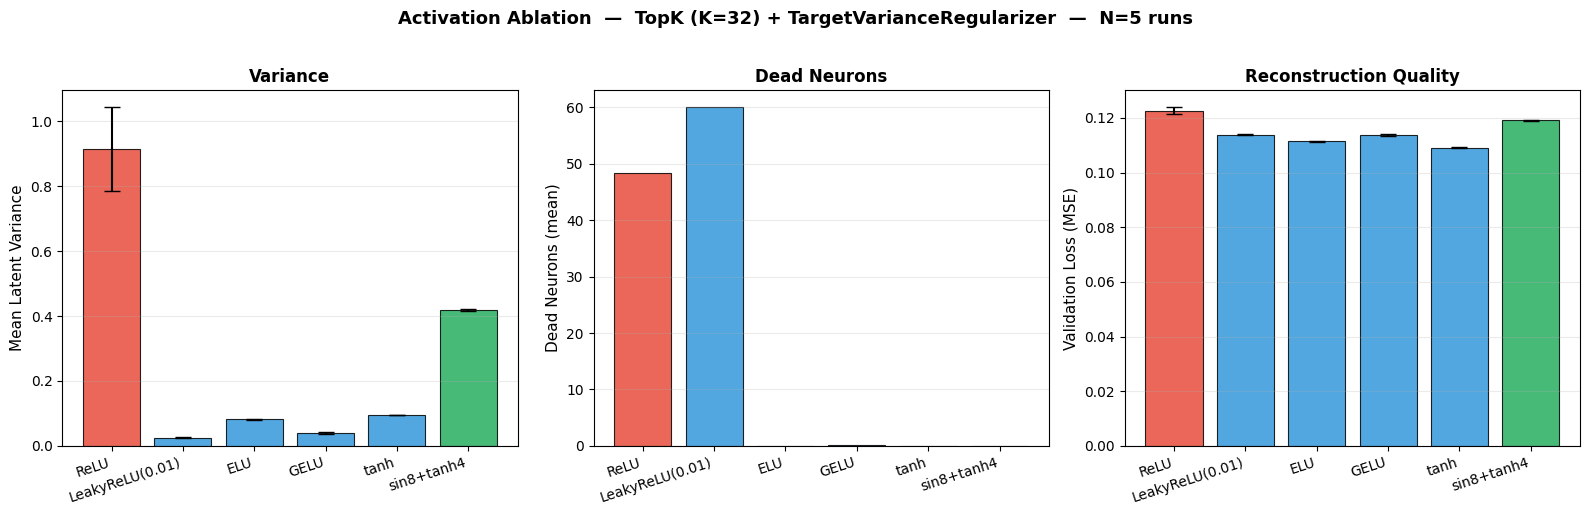

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names  = list(ACTIVATIONS.keys())
x_pos  = np.arange(len(names))
colors = ['#e74c3c' if n == 'ReLU'
          else '#27ae60' if n == 'sin8+tanh4'
          else '#3498db'
          for n in names]

# — Variance —
var_m = [summary[n]['var_mean'] for n in names]
var_s = [summary[n]['var_std']  for n in names]
axes[0].bar(x_pos, var_m, yerr=var_s, capsize=6,
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(names, rotation=18, ha='right', fontsize=10)
axes[0].set_ylabel('Mean Latent Variance', fontsize=11)
axes[0].set_title('Variance', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.25, axis='y')

# — Dead Neurons —
dead_m = [summary[n]['dead_mean'] for n in names]
axes[1].bar(x_pos, dead_m, color=colors, alpha=0.85,
            edgecolor='black', linewidth=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(names, rotation=18, ha='right', fontsize=10)
axes[1].set_ylabel('Dead Neurons (mean)', fontsize=11)
axes[1].set_title('Dead Neurons', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.25, axis='y')

# — Val Loss —
loss_m = [summary[n]['loss_mean'] for n in names]
loss_s = [summary[n]['loss_std']  for n in names]
axes[2].bar(x_pos, loss_m, yerr=loss_s, capsize=6,
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(names, rotation=18, ha='right', fontsize=10)
axes[2].set_ylabel('Validation Loss (MSE)', fontsize=11)
axes[2].set_title('Reconstruction Quality', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.25, axis='y')

fig.suptitle('Activation Ablation  —  TopK (K=32) + TargetVarianceRegularizer  —  N=5 runs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('activation_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
with open('activation_ablation_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)